In [1]:
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth',None)
pd.set_option('display.max_columns',None)

dict_df=pd.read_csv("assets/dictionnaire-69d370bd6c2ee247967691.csv")
data_df=pd.read_csv("assets/data-69d3709338fdb705334215.csv")


# EDA
Nous allons explorer les données dont nous disposons en répondant à quelques questions;
- distinguer les variables discrètes des variables continues
- statistiques descriptives

* Quelles sont les valeurs minimales et maximales de la variable « année_naissance » (essayer de les visualiser à l'aide d'un diagramme en boîte ?) 
* Situation matrimoniale des personnes dont je m'occupe (diagramme à barres?)
* Relation entre kidshome et le revenu (boxplot?)
* Visites sur le Web et leur corrélation avec les achats en ligne (correlation)
* Performance des différentes campagnes (nombre de campagnes acceptées et reponses)


In [2]:
display(data_df.columns)
display(data_df)

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', ' Income ',
       'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntBakedProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Country'],
      dtype='str')

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntBakedProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,104,379,111,189,218,1,4,4,6,1,0,0,0,0,0,1,0,Spain
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,5,64,7,0,37,1,7,3,7,5,0,0,0,0,1,1,0,Canada
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,11,59,15,2,30,1,3,2,5,2,0,0,0,0,0,0,0,USA
3,1386,1967,Graduation,Together,32474.0,1,1,5/11/2014,0,10,0,1,0,0,0,1,1,0,2,7,0,0,0,0,0,0,0,Australia
4,5371,1989,Graduation,Single,21474.0,1,0,4/8/2014,0,6,16,24,11,0,34,2,3,1,2,7,1,0,0,0,0,1,0,Spain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,66476.0,0,1,3/7/2013,99,372,18,126,47,48,78,2,5,2,11,4,0,0,0,0,0,0,0,USA
2236,5263,1977,2n Cycle,Married,31056.0,1,0,1/22/2013,99,5,10,13,3,8,16,1,1,0,3,8,0,0,0,0,0,0,0,Spain
2237,22,1976,Graduation,Divorced,46310.0,1,0,12/3/2012,99,185,2,88,15,5,14,2,6,1,5,8,0,0,0,0,0,0,0,Spain
2238,528,1978,Graduation,Married,65819.0,0,0,11/29/2012,99,267,38,701,149,165,63,1,5,4,10,3,0,0,0,0,0,0,0,India


- Les variables discètes sont: Year_Birth,Education,Marital_Status,Kidhome,Teenhome,Dt_Customer,Recency,  'NumDealsPurchases', 'NumWebPurchases','NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth','AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1','AcceptedCmp2', 'Response', 'Complain', 'Country

- Les variables continues sont: 'Income','MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts'

count    2240.000000
mean     1968.805804
std        11.984069
min      1893.000000
25%      1959.000000
50%      1970.000000
75%      1977.000000
max      1996.000000
Name: Year_Birth, dtype: float64

<Axes: >

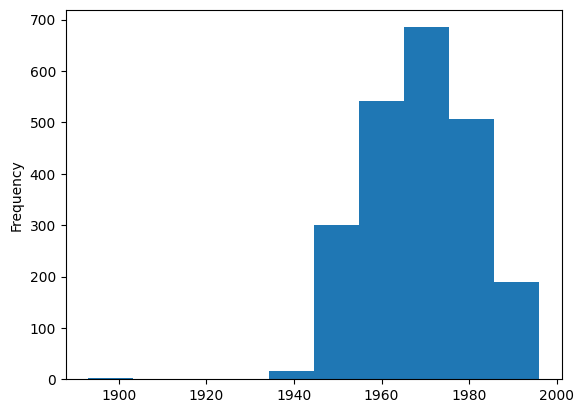

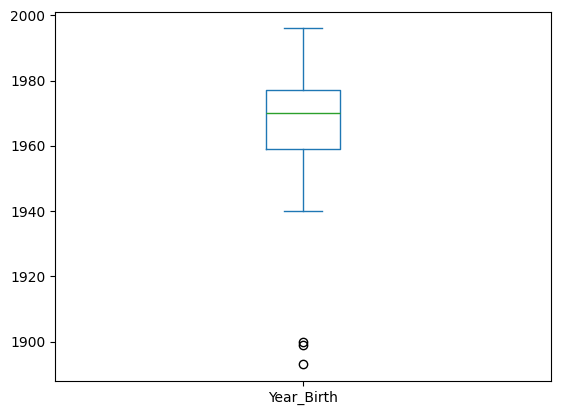

In [3]:
display(data_df['Year_Birth'].describe())
data_df['Year_Birth'].plot(kind='hist')
plt.figure()
data_df['Year_Birth'].plot(kind='box')

nous avons des extremités dans l'age (1890s => 1900s), la variable "date de naissance" de notre population se base entres les années 1940s et 1980s/1990s; avec un Q1 de 1959 (66 ans) et Q3 de 1977 (48 ans)

<Axes: >

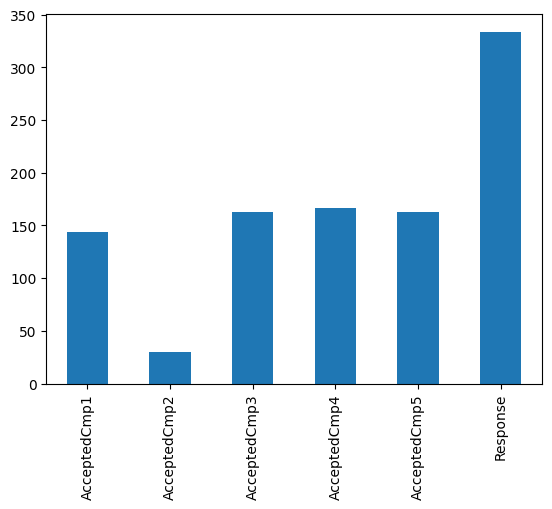

In [4]:
# for each campaign, count the how many people interacted with it:
camp_list=['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']
camp_df=data_df[camp_list].sum(axis=0)
camp_df.plot(kind='bar')

##### this is in seaborn (uncomment the code below) ######

# plt.figure()
# plt.tick_params('x',rotation=90)
# sns.barplot(camp_df)

<Axes: xlabel='count', ylabel='Marital_Status'>

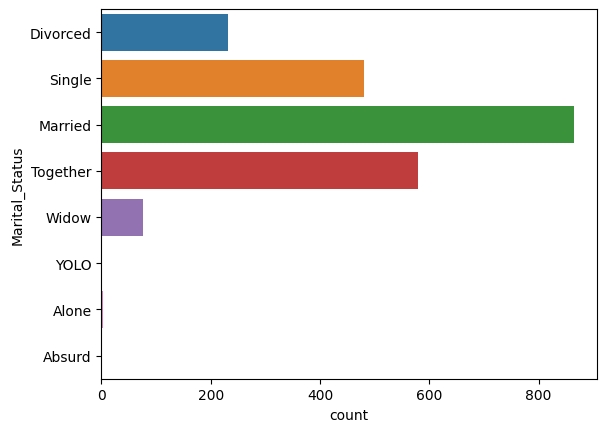

In [5]:
sns.countplot(data=data_df,y='Marital_Status', hue = "Marital_Status")

La majorité de notre clientèle est composée de personnes mariées ou en couple ; les célibataires arrivent en deuxième position, avec un écart minime par rapport au groupe des personnes en couple ; enfin, la minorité de ce groupe est constituée de personnes divorcées, de veuves et d'autres catégories non précisées.

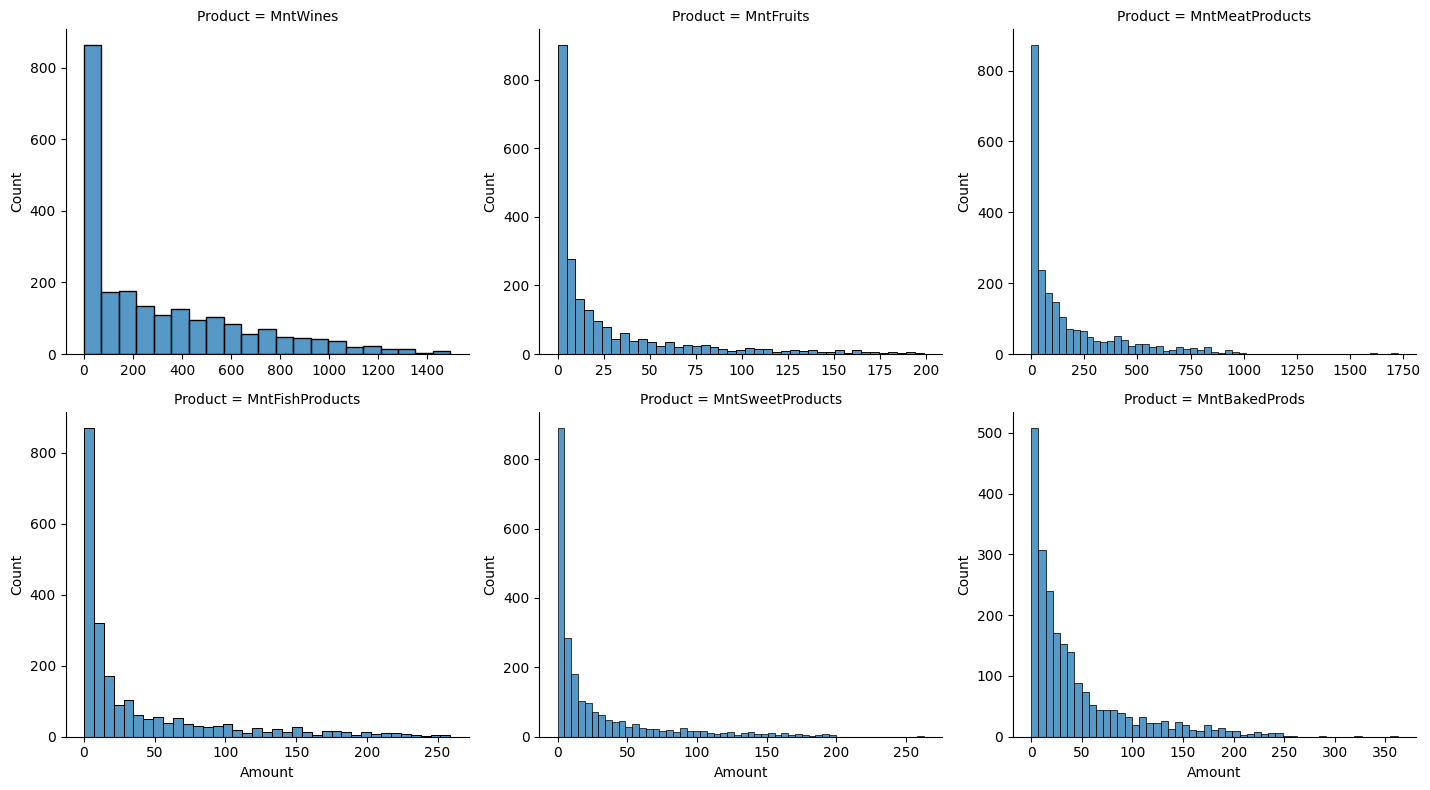

In [6]:
mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntBakedProds']
df_mnt=data_df[mnt_cols].melt(var_name='Product',value_name='Amount')
graph_mnt=sns.FacetGrid(df_mnt, col='Product', col_wrap=3,height=4, aspect=1.2, sharex=False, sharey=False)
graph_mnt.map(sns.histplot, 'Amount')

la distribution du comportement d'achat concernant les différents categories des biens consommables est presque la même ce qui est normale pour le type de clients qu'on étudie (client finale, une personne pas une société)

ce qu'on voit aussi c'est que les clients consomments le vin avec une grande quantité, suivi par les produits carné (viandes) 

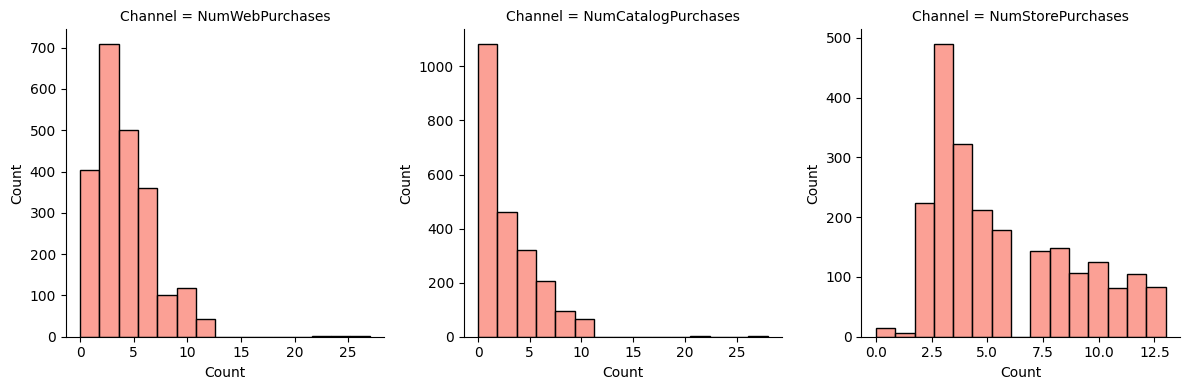

In [7]:
num_cols = [ 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df_num = data_df[num_cols].melt(var_name='Channel', value_name='Count')
g2 = sns.FacetGrid(df_num, col='Channel', col_wrap=3, height=4, sharex=False, sharey=False)
g2.map(sns.histplot, 'Count', bins=15, color='salmon')

Tant pour le nombre d'achats en ligne que pour le nombre d'achats par catalogue, la répartition est assez similaire ; nous examinons ici le nombre de clients ayant effectué n achats via ces canaux (site web/catalogue/magasin) (n correspondant à la valeur sur l'axe des x)

<Axes: xlabel='Teenhome', ylabel=' Income '>

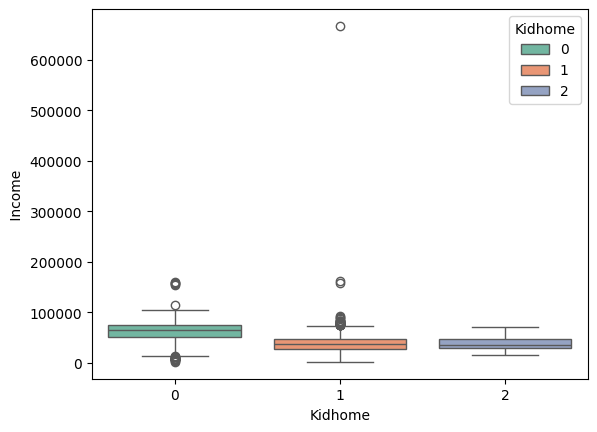

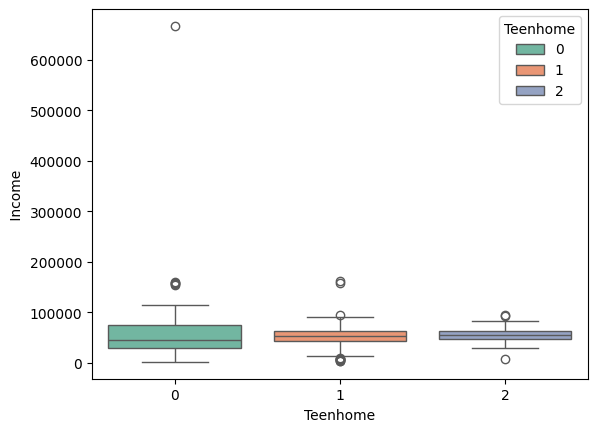

In [8]:
sns.boxplot(data=data_df,x='Kidhome',y=' Income ',hue='Kidhome',palette='Set2')
plt.figure()
sns.boxplot(data=data_df,x='Teenhome',y=' Income ',hue='Teenhome',palette='Set2')

La majorité de la population dispose d'un revenu ne dépassant pas 200 000, tandis que les clients sans enfant affichent une médiane et un Q1 plus élevés, alors que ceux ayant 1 à 2 enfants présentent une médiane et une distribution similaires.

En ce qui concerne la population des foyers avec adolescents, la situation est assez similaire à celle des foyers avec enfants, à cette différence près que la médiane des foyers sans adolescent est inférieure à celle des autres groupes, mais couvre une fourchette plus large (Q1 → Q3).

In [9]:
display(data_df.duplicated())
display(data_df.isnull().sum())
display(data_df.columns)

0       False
1       False
2       False
3       False
4       False
        ...  
2235    False
2236    False
2237    False
2238    False
2239    False
Length: 2240, dtype: bool

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
 Income                24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntBakedProds           0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Response                0
Complain                0
Country                 0
dtype: int64

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', ' Income ',
       'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntBakedProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Country'],
      dtype='str')

# Statistic test
the correlation between the number of times people visit the website & the number of purchases they made in the website (i don't know if it's correlation or contingency) 

In [10]:
#correlation between numwebvisitsmonth & numwebpurchase

heat_map_visits_purchases=pd.crosstab(data_df['NumWebVisitsMonth'],data_df['NumWebPurchases'])
display(heat_map_visits_purchases)

# stats.chi2_contingency(heat_map_visits_purchases)

NumWebPurchases,0,1,2,3,4,5,6,7,8,9,10,11,23,25,27
NumWebVisitsMonth,,,,,,,,,,,,,,,
0,5,1,2,2,0,0,0,0,0,0,0,0,1,0,0
1,3,4,26,61,42,12,2,0,0,0,0,0,0,1,2
2,1,12,9,26,67,51,30,6,0,0,0,0,0,0,0
3,5,18,14,22,36,38,42,17,10,2,1,0,0,0,0
4,7,34,28,20,18,18,34,31,15,7,3,3,0,0,0
5,8,40,62,20,25,27,22,35,14,20,3,5,0,0,0
6,7,56,82,38,22,22,23,20,26,19,12,13,0,0,0
7,5,99,83,56,32,18,30,17,23,13,7,10,0,0,0
8,2,76,54,70,28,28,16,22,13,10,13,10,0,0,0




sommes des différents montants dans une seules colonne

* vérifié l'impactes des campaigns marketing sur les ventes (students, anova, chisquare (2 discrete) )
* voir la independance entre 2 catégories (Education vs Country)

In [ ]:
data_df['Total_Amount_Spent']=data_df[['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntBakedProds']].sum(axis='columns')

for campaign in camp_list:
    grp_current_campaing_no=data_df[data_df[campaign]==0]['Total_Amount_Spent']
    grp_current_campaing_yes=data_df[data_df[campaign]==1]['Total_Amount_Spent']
    testt_indp=stats.ttest_ind(grp_current_campaing_yes,grp_current_campaing_no,equal_var=False)
    test_anova=stats.f_oneway(grp_current_campaing_yes,grp_current_campaing_no,equal_var=False)
    print("=======================")
    print(f"Le résultat du test t d'indépendance pour {campaign} est : {(testt_indp.statistic,testt_indp.pvalue)}")
    print(f"Le résultat du test ANOVA pour {campaign} est : {(test_anova.statistic,test_anova.pvalue)}")


Le résultat du test t d'indépendance pour AcceptedCmp1 est : (np.float64(21.279565568730288), np.float64(1.5515667359182744e-49))
Le résultat du test ANOVA pour AcceptedCmp1 est : (np.float64(452.8199107938915), np.float64(1.5515667359182438e-49))
Le résultat du test t d'indépendance pour AcceptedCmp2 est : (np.float64(6.960913368391416), np.float64(1.0009916826658597e-07))
Le résultat du test ANOVA pour AcceptedCmp2 est : (np.float64(48.454314922250326), np.float64(1.0009916826658597e-07))
Le résultat du test t d'indépendance pour AcceptedCmp3 est : (np.float64(2.2070333570281133), np.float64(0.02856969347991298))
Le résultat du test ANOVA pour AcceptedCmp3 est : (np.float64(4.870996239034783), np.float64(0.028569693479912978))
Le résultat du test t d'indépendance pour AcceptedCmp4 est : (np.float64(12.157612236461969), np.float64(1.3224208389447318e-25))
Le résultat du test ANOVA pour AcceptedCmp4 est : (np.float64(147.80753529216975), np.float64(1.322420838944732e-25))
Le résultat d

In [12]:
test_chisquare_2=pd.crosstab(data_df['Education'],data_df['Kidhome'])
test_chisquare_3=pd.crosstab(data_df['Education'],data_df['Country'])
display(test_chisquare_3,test_chisquare_2)
test_chisquare_2=stats.chi2_contingency(test_chisquare_2)
test_chisquare_3=stats.chi2_contingency(test_chisquare_3)
display(test_chisquare_2.pvalue,test_chisquare_3.pvalue)

Country,Australia,Canada,Germany,India,Mexico,Saudi Arabia,Spain,USA
Education,,,,,,,,
2n Cycle,9,24,20,21,0,25,97,7
Basic,4,7,2,4,0,6,28,3
Graduation,85,133,59,76,1,161,548,64
Master,32,49,20,21,1,60,171,16
PhD,30,55,19,26,1,85,251,19


Kidhome,0,1,2
Education,,,
2n Cycle,109,91,3
Basic,20,34,0
Graduation,650,453,24
Master,211,150,9
PhD,303,171,12


np.float64(0.01251023044090985)

np.float64(0.30413445879831413)

# Check different correlation between different demographic & customer behavior

In [13]:
# Tal mn B3D 
# ta nsali power bi

In [14]:
data_df['total_campaings_accepted']=data_df[['AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','AcceptedCmp1','AcceptedCmp2','Response']].sum(axis=1)
# data_df['total_campaings_accepted'].value_counts()
data_df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntBakedProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Total_Amount_Spent,total_campaings_accepted
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,104,379,111,189,218,1,4,4,6,1,0,0,0,0,0,1,0,Spain,1190,1
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,5,64,7,0,37,1,7,3,7,5,0,0,0,0,1,1,0,Canada,577,2
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,11,59,15,2,30,1,3,2,5,2,0,0,0,0,0,0,0,USA,251,0
3,1386,1967,Graduation,Together,32474.0,1,1,5/11/2014,0,10,0,1,0,0,0,1,1,0,2,7,0,0,0,0,0,0,0,Australia,11,0
4,5371,1989,Graduation,Single,21474.0,1,0,4/8/2014,0,6,16,24,11,0,34,2,3,1,2,7,1,0,0,0,0,1,0,Spain,91,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,66476.0,0,1,3/7/2013,99,372,18,126,47,48,78,2,5,2,11,4,0,0,0,0,0,0,0,USA,689,0
2236,5263,1977,2n Cycle,Married,31056.0,1,0,1/22/2013,99,5,10,13,3,8,16,1,1,0,3,8,0,0,0,0,0,0,0,Spain,55,0
2237,22,1976,Graduation,Divorced,46310.0,1,0,12/3/2012,99,185,2,88,15,5,14,2,6,1,5,8,0,0,0,0,0,0,0,Spain,309,0
2238,528,1978,Graduation,Married,65819.0,0,0,11/29/2012,99,267,38,701,149,165,63,1,5,4,10,3,0,0,0,0,0,0,0,India,1383,0


<Axes: xlabel=' Income ', ylabel='Count'>

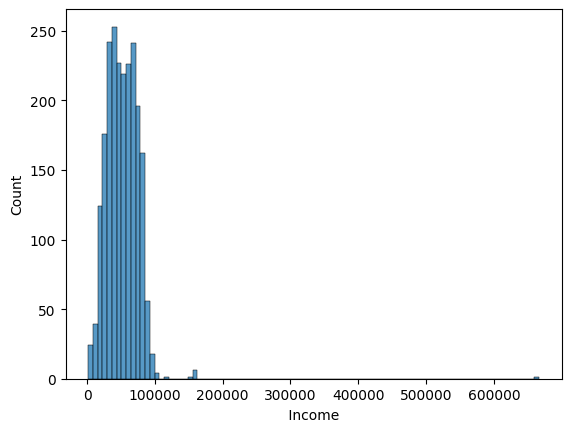

In [15]:
# # Mean of income for each country

# countrygroup=data_df.groupby('Country')[' Income ']
# # countrygroup.mean().plot(kind='bar')
# sns.boxplot(data=data_df,x='Country',y=' Income ',hue='Country')
# sns.histplot(data=data_df,y=' Income ')

sns.histplot(data=data_df,x=' Income ')
